***Step 1: Install required libraries***

In [2]:
!pip install pycuda opencv-python
!pip install scikit-image opencv-python
!sudo apt install tesseract-ocr
!pip install pytesseract opencv-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2024.1.2-cp310-cp310-linux_x86_64.whl size=660545 sha256=1ecc4aac01cc931f6c61fa90d2e0aa5e10f52bde8eca986d2762feb90ae352fe
  Stored in directory: /root/.cache/pip/wheels/70/63/40/4bf006182f942d3516b71bb2ff3b57ccbdb8b2c0ee81882b6e
Successfully built pycuda
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove an

***Step 2 : Import required libraries***

In [3]:
import numpy as np
import pytesseract
import cv2
import pycuda.autoinit
import pycuda.driver as drv
from pycuda.compiler import SourceModule
from google.colab import files
from matplotlib import pyplot as plt
from skimage import restoration
import time

***Step 3 : Upload the image from your local machine***

In [4]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

Saving j.jpg to j.jpg


***Step 4 : Resize Images***

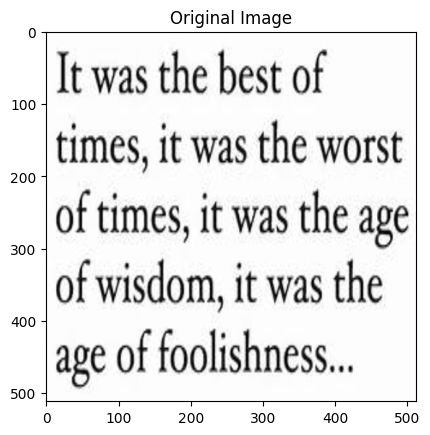

In [5]:
img = cv2.resize(img, (512, 512))

if img is None:
    print("Error: Image not loaded. Check the file path.")
else:
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.show()

***Step 5 : Implement Image Deblurring***

/usr/local/lib/python3.10/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: module in out-of-thread context could not be cleaned up
  globals().clear()


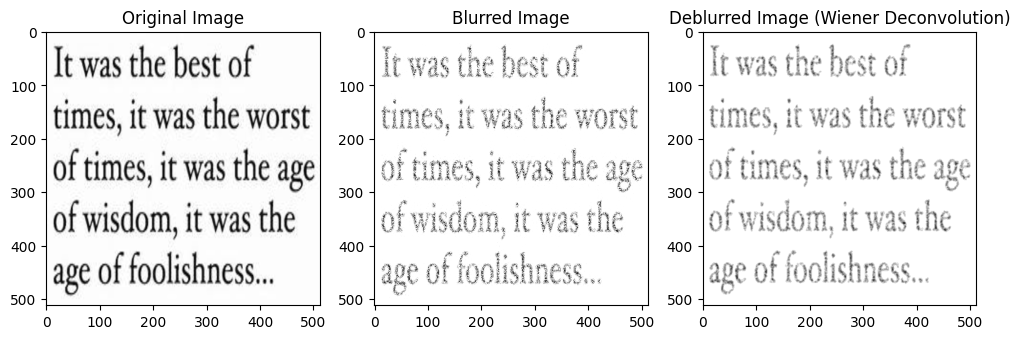

In [10]:
# Step 4: Define the Wiener deconvolution function
def wiener_deconvolution(blurred_img, kernel, noise_var):
    kernel_ft = np.fft.fft2(kernel, s=blurred_img.shape)
    blurred_ft = np.fft.fft2(blurred_img)
    wiener_filter = np.conj(kernel_ft) / (np.abs(kernel_ft) ** 2 + noise_var)
    deconvolved_ft = wiener_filter * blurred_ft
    deconvolved_img = np.fft.ifft2(deconvolved_ft)
    return np.abs(deconvolved_img).astype(np.uint8)

# Step 5: Define the CUDA kernel for sharpening (as an example)
cuda_kernel_code = """
__global__ void sharpenKernel(unsigned char *input, unsigned char *output, int width, int height) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x > 0 && x < width - 1 && y > 0 && y < height - 1) {
        int idx = y * width + x;

        // Apply a simple sharpening filter
        int value = (5 * input[idx])
                    - input[idx - 1]
                    - input[idx + 1]
                    - input[idx - width]
                    - input[idx + width];

        // Clamp the result to a valid pixel range
        output[idx] = min(max(value, 0), 255);
    }
}
"""

# Step 6: Create the kernel and prepare CUDA function
mod = SourceModule(cuda_kernel_code)
sharpenKernel = mod.get_function("sharpenKernel")

# Step 7: Define the kernel for simulation (Gaussian kernel for Wiener)
gaussian_kernel = np.array([[1, 4, 6, 4, 1],
                             [4, 16, 24, 16, 4],
                             [6, 24, 36, 24, 6],
                             [4, 16, 24, 16, 4],
                             [1, 4, 6, 4, 1]]) / 256

# Step 8: Measure CPU performance
start_time = time.time()
# Adding noise to the image (for simulation purposes)
noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
blurred_img = cv2.add(img, noise)

# Perform Wiener deconvolution on CPU
deconvolved_cpu = wiener_deconvolution(blurred_img, gaussian_kernel, noise_var=25)
cpu_time = time.time() - start_time

# Step 9: Measure GPU performance
input_image = blurred_img.astype(np.uint8)
output_image = np.empty_like(input_image)

# Prepare data for GPU
block_size = (16, 16, 1)  # Block size for CUDA kernel
grid_size = (input_image.shape[1] // block_size[0] + 1, input_image.shape[0] // block_size[1] + 1)

start_time_gpu = time.time()
# Run the kernel for sharpening (as an example)
sharpenKernel(
    drv.In(input_image),
    drv.Out(output_image),
    np.int32(input_image.shape[1]),
    np.int32(input_image.shape[0]),
    block=block_size,
    grid=grid_size
)
gpu_time = time.time() - start_time_gpu

# Step 10: Display the results
plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Blurred Image")
plt.imshow(blurred_img, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Deblurred Image (Wiener Deconvolution)")
plt.imshow(deconvolved_cpu, cmap='gray')
plt.show()

# Convert the image to RGB (Tesseract works better with RGB images)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

***Step 6: Perform OCR to extract text***

In [11]:
# Step 5: Perform OCR to extract text
extracted_text = pytesseract.image_to_string(img_rgb)

In [12]:
# Print the extracted text
print("Extracted Text:")
print(extracted_text)

Extracted Text:
It was the best of
times, it was the worst
of times, it was the age
of wisdom, it was the
age of foolishness...



***Step 7 : Performance***

In [13]:
# Print performance results
print(f"CPU Execution Time for Wiener Deconvolution: {cpu_time:.4f} seconds")
print(f"GPU Execution Time for Sharpening: {gpu_time:.4f} seconds")

CPU Execution Time for Wiener Deconvolution: 0.0349 seconds
GPU Execution Time for Sharpening: 0.0009 seconds
